In [ ]:
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
torch.manual_seed(123)

## Problem Overview: 1D Ordinary Differential Equation

We are using a Physics-Informed Neural Network (PINN) to solve the following first-order ordinary differential equation:

$$\frac{dy}{dx} = x$$

### Domain and Conditions
- **Domain**: $x \in [0, 1]$
- **Initial Condition**: $y(0) = 0$

### Exact Solution
The analytical solution for this specific problem is:
$$y(x) = \frac{x^2}{2}$$

In [ ]:
def exact_solution(x):
    """
    Defines the analytical solution: y = 1/2 * x^2
    """
    return (x**2)/2

class FCN(nn.Module):
    """
    Defines a fully-connected network in PyTorch
    """
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

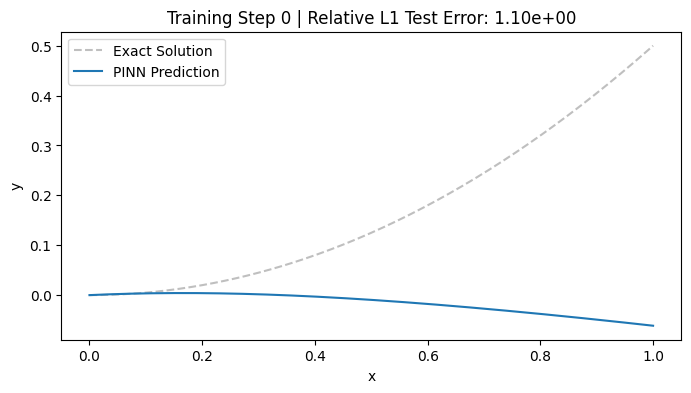

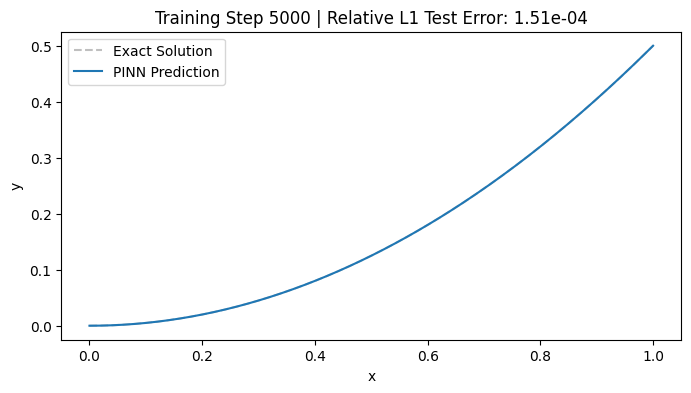

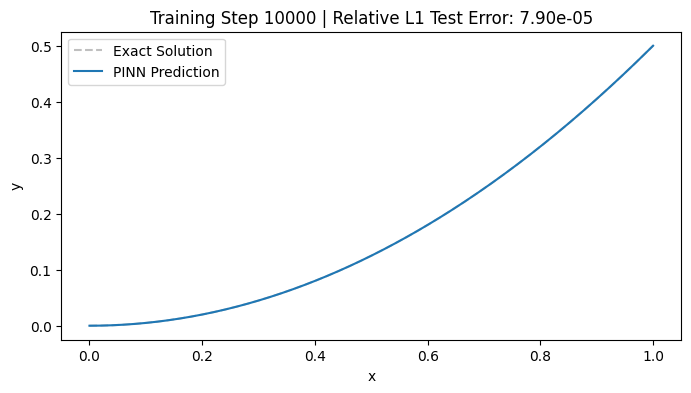

Total training time: 21.66 seconds


In [ ]:
# 1. Setup Network and Data
pinn = FCN(1, 1, 32, 3) # Input: x, Output: y

# Define boundary point (x=0)
x_boundary = torch.tensor([[0.0]], requires_grad=True)

# Define collocation points for physics loss (x in [0,1])
x_physics = torch.linspace(0, 1, 30).view(-1, 1).requires_grad_(True)

# For evaluation
x_test = torch.linspace(0, 1, 300).view(-1, 1)
y_exact = exact_solution(x_test)

optimiser = torch.optim.Adam(pinn.parameters(), lr=1e-3)

# 2. Training Loop
start_time = time.time()
for i in range(10001): # Assuming you want to re-run for 10000 steps
    optimiser.zero_grad()

    # --- Hard-Embedding Trial Form ---
    # Based on Slide 28: u(t) = u0 + f(t)*t
    u0 = 0
    t = x_physics - 0.0  # Shifted coordinate

    y = pinn(x_physics)
    y_pred = u0 + (t * y)

    # --- Physics Loss (Automatic Differentiation) ---
    # PyTorch handles the complex product rule for y', y'' automatically
    dydx = torch.autograd.grad(y_pred, x_physics, torch.ones_like(y_pred), create_graph=True)[0]

    # Residual:
    physics_residual =  dydx - x_physics
    loss = torch.mean(physics_residual**2)

    loss.backward()
    optimiser.step()

    # 3. Visualization
    if i % 5000 == 0:
        # You must apply the trial form to the test data for the plot to be correct
        t_test = x_test - 0.0
        y_pred = (u0 + (pinn(x_test) * t_test)).detach()
        # Calculate relative L1 test error
        relative_l1_error = torch.sum(torch.abs(y_pred - y_exact)) / torch.sum(torch.abs(y_exact))

        plt.figure(figsize=(8, 4))
        plt.plot(x_test, y_exact, label="Exact Solution", color="grey", alpha=0.5, linestyle="--")
        plt.plot(x_test, y_pred, label="PINN Prediction", color="tab:blue")
        plt.title(f"Training Step {i} | Relative L1 Test Error: {relative_l1_error.item():.2e}")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        plt.show()

print(f"Total training time: {time.time() - start_time:.2f} seconds")

## Inverse Problem Overview: Parameter Estimation

In an *inverse problem*, instead of solving for the state of the system given known parameters, we use observed data to infer unknown parameters of the system. Here, we aim to estimate an unknown parameter (which we'll call `alpha`) in our ODE $\frac{dy}{dx} = \alpha x$, given some noisy measurements of $y(x)$.

### Problem Statement
- **Governing Equation**: $\frac{dy}{dx} = \alpha x$
- **Domain**: $x \in [0, 1]$
- **Initial Condition**: $y(0) = 0$

### Goal
Infer the value of $\alpha$ using observed data, knowing that the true value of $\alpha$ is $1.0$ (leading to the exact solution $y(x) = \frac{x^2}{2}$).

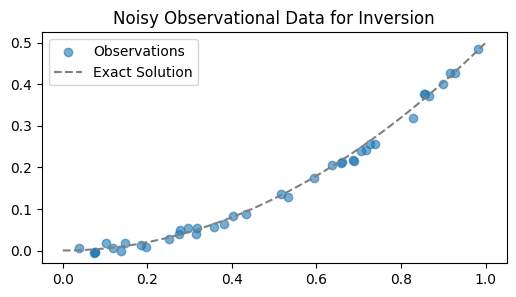

In [ ]:
# 1. Create noisy observational data
torch.manual_seed(123)
# The true value we want to recover is 1.0
true_alpha = 1.0

# Generate 40 random points in the domain [0, 1]
x_obs = (torch.rand(40)).view(-1,1)
# Calculate exact y values and add Gaussian noise
y_obs = exact_solution(x_obs) + 0.01 * torch.randn_like(x_obs)

# For plotting
x_test = torch.linspace(0, 1, 300).view(-1, 1)
y_exact = exact_solution(x_test)

plt.figure(figsize=(6, 3))
plt.title("Noisy Observational Data for Inversion")
plt.scatter(x_obs.detach(), y_obs.detach(), label="Observations", alpha=0.6)
plt.plot(x_test, y_exact, label="Exact Solution", color="grey", linestyle="--")
plt.legend()
plt.show()

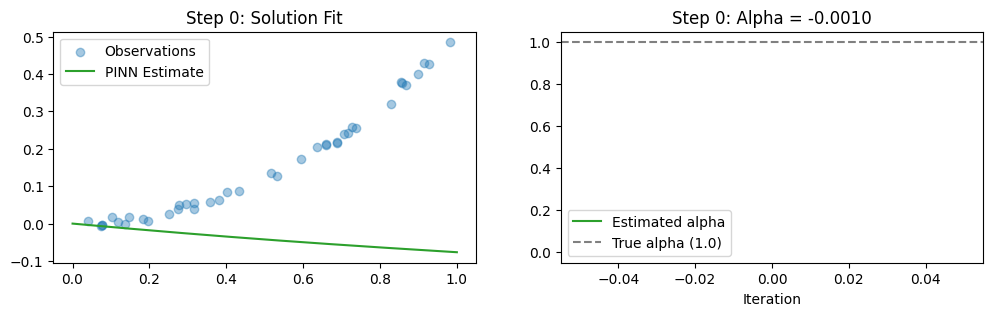

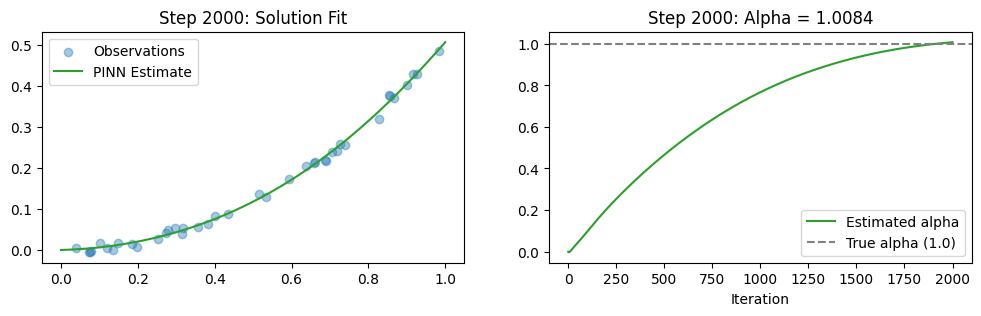

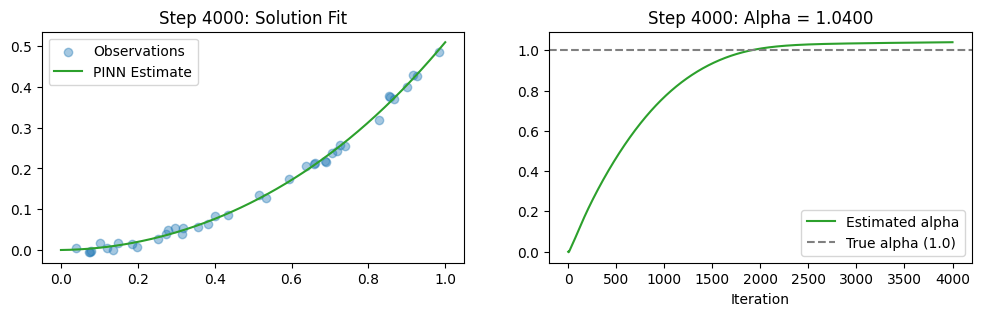

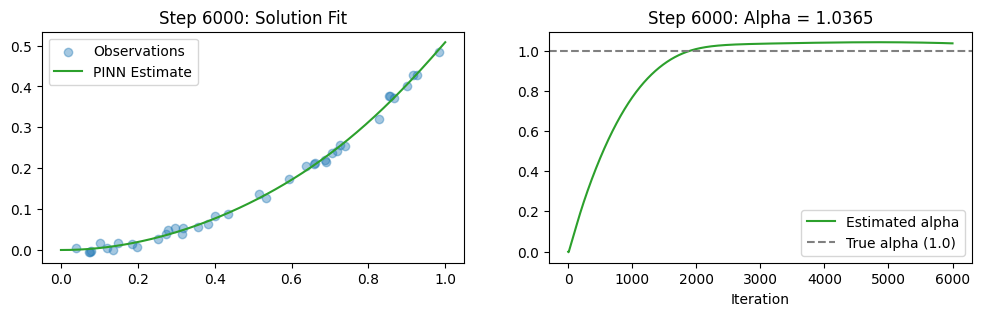

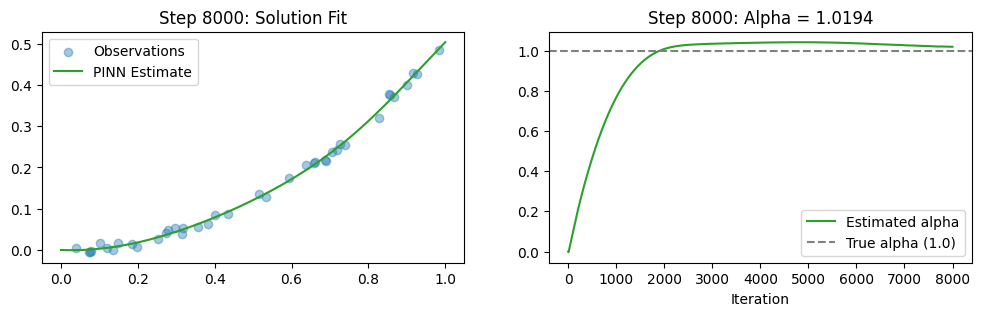

Total training time: 24.21 seconds
Final estimated alpha: 1.0194


In [ ]:
# 1. Setup Network and the Unknown Parameter
pinn_inv = FCN(1, 1, 32, 3)

# Initialize alpha with a guess (e.g., 0.0)
alpha = torch.nn.Parameter(torch.tensor([0.0], requires_grad=True))

# Define collocation points for the physics loss
x_physics = torch.linspace(0, 1, 50).view(-1, 1).requires_grad_(True)

# Add both PINN weights and the unknown parameter alpha to the optimizer
optimiser = torch.optim.Adam(list(pinn_inv.parameters()) + [alpha], lr=1e-3)

# 2. Training Loop
alphas = []
start_time = time.time()

for i in range(8001):
    optimiser.zero_grad()

    # --- Hard-Embedding Trial Form (Physics Points) ---
    u0 = 0
    t_phy = x_physics - 0.0  # Shift boundary

    # Trial form: y = y0 + v0*t + t^2 * f(t)
    nn_phy = pinn_inv(x_physics)
    y_phy_pred = u0 + (nn_phy * t_phy)

    # Compute derivatives of the trial form
    dydx = torch.autograd.grad(y_phy_pred, x_physics, torch.ones_like(y_phy_pred), create_graph=True)[0]

    # Equation: y' = x
    res = dydx - alpha * x_physics
    loss_physics = torch.mean(res**2)

    # --- Data Loss (Using Trial Form) ---
    t_obs = x_obs - 0.0
    nn_obs = pinn_inv(x_obs)
    y_obs_pred = u0 + (nn_obs * t_obs)

    # Minimize difference with noisy observations
    loss_data = torch.mean((y_obs_pred - y_obs)**2)

    # Total Loss (lambda balances physics consistency with data fit)
    lambda_data = 1e4
    loss = loss_physics + lambda_data * loss_data

    loss.backward()
    optimiser.step()

    alphas.append(alpha.item())

    # 3. Visualization
    if i % 2000 == 0:
        # --- Visualization Update ---
        t_test = x_test - 0.0
        y_test_pred = (u0 + (pinn_inv(x_test) * t_test)).detach()

        plt.figure(figsize=(12, 3))
        # Subplot 1: Solution Fit
        plt.subplot(1, 2, 1)
        plt.scatter(x_obs.detach(), y_obs.detach(), alpha=0.4, label="Observations")
        plt.plot(x_test, y_test_pred, color="tab:green", label="PINN Estimate")
        plt.title(f"Step {i}: Solution Fit")
        plt.legend()

        # Subplot 2: Parameter Convergence
        plt.subplot(1, 2, 2)
        plt.plot(alphas, color="tab:green", label="Estimated alpha")
        plt.axhline(y=true_alpha, color="grey", linestyle="--", label="True alpha (1.0)")
        plt.title(f"Step {i}: Alpha = {alpha.item():.4f}")
        plt.xlabel("Iteration")
        plt.legend()
        plt.show()

print(f"Total training time: {time.time() - start_time:.2f} seconds")
print(f"Final estimated alpha: {alpha.item():.4f}")